### Description

This notebook implements a neural network for regression from scratch using a custom
neural network framework built with NumPy.

Dataset:
California Housing Dataset

Goal:
Predict median housing price based on district features.

### Import Libraries

In [1]:
import sys
import os

# Add the parent directory to Python path
sys.path.append(os.path.abspath(".."))

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from framework.layers import Linear
from framework.activations import ReLU
from framework.losses import MSELoss
from framework.model import NeuralNetwork
from framework.optimizer import SGD
from framework.trainer import Trainer

from datasets.housing_dataset import HousingDataset

### Load Dataset

In [3]:
dataset = HousingDataset()

X_train, X_test, y_train, y_test = dataset.load()

print("Training samples:", X_train.shape)
print("Test samples:", X_test.shape)

Training samples: (16512, 8)
Test samples: (4128, 8)


### Build Neural Network

In [4]:
model = NeuralNetwork()

model.add(Linear(8,64))
model.add(ReLU())

model.add(Linear(64,32))
model.add(ReLU())

model.add(Linear(32,1))

### Training Configuration

In [5]:
loss = MSELoss()

optimizer = SGD(lr=0.001)

trainer = Trainer(model, loss, optimizer)

### Train Model

In [6]:
losses = trainer.train(
    X_train,
    y_train,
    epochs=100
)

Epoch 0 Loss 5.6297
Epoch 1 Loss 5.6125
Epoch 2 Loss 5.5954
Epoch 3 Loss 5.5784
Epoch 4 Loss 5.5614
Epoch 5 Loss 5.5445
Epoch 6 Loss 5.5277
Epoch 7 Loss 5.5110
Epoch 8 Loss 5.4943
Epoch 9 Loss 5.4776
Epoch 10 Loss 5.4611
Epoch 11 Loss 5.4446
Epoch 12 Loss 5.4281
Epoch 13 Loss 5.4118
Epoch 14 Loss 5.3955
Epoch 15 Loss 5.3792
Epoch 16 Loss 5.3631
Epoch 17 Loss 5.3470
Epoch 18 Loss 5.3309
Epoch 19 Loss 5.3149
Epoch 20 Loss 5.2990
Epoch 21 Loss 5.2832
Epoch 22 Loss 5.2674
Epoch 23 Loss 5.2517
Epoch 24 Loss 5.2360
Epoch 25 Loss 5.2204
Epoch 26 Loss 5.2049
Epoch 27 Loss 5.1894
Epoch 28 Loss 5.1740
Epoch 29 Loss 5.1586
Epoch 30 Loss 5.1433
Epoch 31 Loss 5.1281
Epoch 32 Loss 5.1129
Epoch 33 Loss 5.0978
Epoch 34 Loss 5.0828
Epoch 35 Loss 5.0678
Epoch 36 Loss 5.0528
Epoch 37 Loss 5.0380
Epoch 38 Loss 5.0232
Epoch 39 Loss 5.0084
Epoch 40 Loss 4.9937
Epoch 41 Loss 4.9791
Epoch 42 Loss 4.9645
Epoch 43 Loss 4.9500
Epoch 44 Loss 4.9355
Epoch 45 Loss 4.9211
Epoch 46 Loss 4.9068
Epoch 47 Loss 4.8925
Ep

### Plot Training Loss

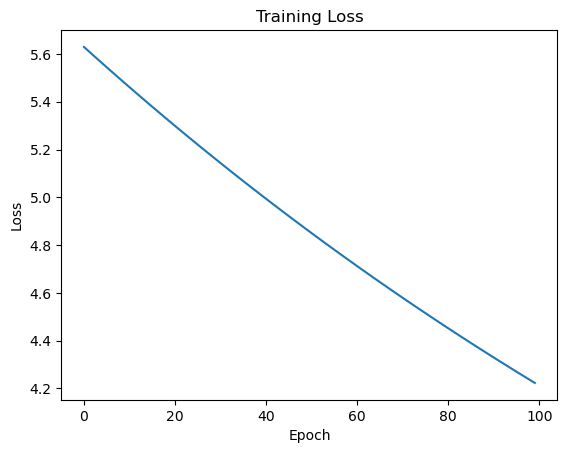

In [7]:
plt.plot(losses)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

### Evaluate Model

In [8]:
y_pred = model.forward(X_test)

mse = np.mean((y_pred - y_test)**2)

print("Test MSE:", mse)

Test MSE: 4.127948436476523


### Conclusion

The neural network successfully learns the relationship between
housing features and price.

Training loss decreases steadily, demonstrating that gradient
descent successfully optimized the network parameters.